In [1]:
!pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn joblib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving rfm_modeling_snapshot.csv to rfm_modeling_snapshot.csv


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

import shap
import joblib
import json

In [4]:
df = pd.read_csv(
    "rfm_modeling_snapshot.csv"
)

df.shape

(2400, 29)

In [5]:
leakage_columns = [

    "churn_next_60d"

]

print(
    leakage_columns
)

['churn_next_60d']


In [6]:
train = df[
    df["split"]=="train"
]

valid = df[
    df["split"]=="validation"
]

test = df[
    df["split"]=="test"
]

In [7]:
target = "churn_next_60d"

drop_cols = [

    "customer_id",

    "snapshot_date",

    "split",

    target
]

features = [
    c for c in df.columns
    if c not in drop_cols
]

In [8]:
X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

In [9]:
cat_cols = (
    X_train
    .select_dtypes(
        include="object"
    )
    .columns
    .tolist()
)

num_cols = [
    c for c in X_train.columns
    if c not in cat_cols
]

In [10]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            SimpleImputer(
                strategy="median"
            ),

            num_cols

        ),

        (

            "cat",

            Pipeline([

                (

                    "imputer",

                    SimpleImputer(
                        strategy="most_frequent"
                    )

                ),

                (

                    "encoder",

                    OneHotEncoder(
                        handle_unknown="ignore"
                    )

                )

            ]),

            cat_cols

        )

    ]

)

In [11]:
lr_model = Pipeline([

    ("preprocessor",preprocessor),

    (

        "model",

        LogisticRegression(
            max_iter=1000
        )

    )

])

In [12]:
lr_model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['recency_days',
                                                   'frequency_180d',
                                                   'monetary_180d',
                                                   'return_rate_180d',
                                                   'avg_discount_pct_180d',
                                                   'avg_rating_180d',
                                                   'category_diversity_180d',
                                                   'ticket_count_90d',
                                                   'negative_ticket_rate_90d',
                                                   'avg_resolution_hours_90d',
                                                   'days_since_signup',
                                                   'sessions_30d',
                                                   'p...
                                                   'abandoned_carts_30d',
                                                   'email_opens_30d',
                                                   'campaign_clicks_30d',
                                                   'last_visit_days_ago']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city_tier', 'age_group',
                                                   'acquisition_channel',
                                                   'loyalty_tier',
                                                   'preferred_category',
                                                   'marketing_consent'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [13]:
lr_prob = (
    lr_model
    .predict_proba(X_valid)
    [:,1]
)

In [14]:
roc_auc_score(
    y_valid,
    lr_prob
)

np.float64(0.8830219918655293)

In [15]:
rf_model = Pipeline([

    ("preprocessor",preprocessor),

    (

        "model",

        RandomForestClassifier(

            n_estimators=500,

            max_depth=10,

            min_samples_leaf=5,

            random_state=42

        )

    )

])

In [16]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['recency_days',
                                                   'frequency_180d',
                                                   'monetary_180d',
                                                   'return_rate_180d',
                                                   'avg_discount_pct_180d',
                                                   'avg_rating_180d',
                                                   'category_diversity_180d',
                                                   'ticket_count_90d',
                                                   'negative_ticket_rate_90d',
                                                   'avg_resolution_hours_90d',
                                                   'days_since_signup',
                                                   'sessions_30d',
                                                   'p...
                                                   'last_visit_days_ago']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city_tier', 'age_group',
                                                   'acquisition_channel',
                                                   'loyalty_tier',
                                                   'preferred_category',
                                                   'marketing_consent'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=5,
                                        n_estimators=500, random_state=42))])

In [17]:
rf_prob = (
    rf_model
    .predict_proba(X_valid)
    [:,1]
)

In [18]:
roc_auc_score(
    y_valid,
    rf_prob
)

np.float64(0.8805744520030234)

In [19]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

results = []

for t in thresholds:

    pred = (
        rf_prob >= t
    ).astype(int)

    results.append([

        t,

        precision_score(
            y_valid,
            pred
        ),

        recall_score(
            y_valid,
            pred
        ),

        f1_score(
            y_valid,
            pred
        )

    ])

In [20]:
threshold_df = pd.DataFrame(

    results,

    columns=[

        "threshold",

        "precision",

        "recall",

        "f1"

    ]

)

In [22]:
BEST_THRESHOLD = 0.40

In [23]:
test_prob = (
    rf_model
    .predict_proba(X_test)
    [:,1]
)

test_pred = (
    test_prob >= BEST_THRESHOLD
).astype(int)

In [24]:
accuracy = accuracy_score(
    y_test,
    test_pred
)

precision = precision_score(
    y_test,
    test_pred
)

recall = recall_score(
    y_test,
    test_pred
)

f1 = f1_score(
    y_test,
    test_pred
)

roc_auc = roc_auc_score(
    y_test,
    test_prob
)

pr_auc = average_precision_score(
    y_test,
    test_prob
)

In [28]:
rf = rf_model.named_steps[
    "model"
]

importances = rf.feature_importances_

In [30]:
joblib.dump(
    rf_model,
    "model.pkl"
)

['model.pkl']

In [31]:
metrics = {

    "accuracy": float(
        accuracy
    ),

    "precision": float(
        precision
    ),

    "recall": float(
        recall
    ),

    "f1": float(
        f1
    ),

    "roc_auc": float(
        roc_auc
    ),

    "pr_auc": float(
        pr_auc
    ),

    "threshold": BEST_THRESHOLD,

    "confusion_matrix": cm.tolist()

}

with open(
    "metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [32]:
feature_corr = (
    df.select_dtypes(
        exclude="object"
    )
    .corr()
)

feature_corr[
    "churn_next_60d"
].sort_values()

,churn_next_60d
frequency_180d,-0.393999
monetary_180d,-0.384785
category_diversity_180d,-0.382854
sessions_30d,-0.307330
product_views_30d,-0.287175
cart_adds_30d,-0.248782
wishlist_adds_30d,-0.232018
abandoned_carts_30d,-0.216053
avg_discount_pct_180d,-0.190569
ticket_count_90d,-0.152700


In [33]:
metrics = {

    "accuracy":
    accuracy_score(
        y_test,
        test_pred
    ),

    "precision":
    precision_score(
        y_test,
        test_pred
    ),

    "recall":
    recall_score(
        y_test,
        test_pred
    ),

    "f1":
    f1_score(
        y_test,
        test_pred
    ),

    "roc_auc":
    roc_auc_score(
        y_test,
        test_prob
    ),

    "pr_auc":
    average_precision_score(
        y_test,
        test_prob
    )

}

metrics

{'accuracy': 0.8303571428571429,
 'precision': 0.8032786885245902,
 'recall': 0.875,
 'f1': 0.8376068376068376,
 'roc_auc': np.float64(0.8844600340136055),
 'pr_auc': np.float64(0.8688391530538858)}

In [34]:
import json

with open(
    "metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [35]:
results = X_test.copy()

results[
    "actual"
] = y_test.values

results[
    "predicted"
] = test_pred

results[
    "probability"
] = test_prob

false_positives = results[
    (results["actual"]==0)
    &
    (results["predicted"]==1)
]

false_positives.head(10)

,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,...,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,actual,predicted,probability
43,Tier 2,35-44,Google Search,NaN,Baby Care,Yes,72,1,899.51,0.0,...,27,2,1,1,4,2,10,0,1,0.473767
108,Tier 1,25-34,Instagram,Silver,Skin Care,Yes,92,2,1622.28,0.0,...,4,0,0,0,3,1,16,0,1,0.579209
334,Tier 2,45+,Instagram,NaN,Skin Care,Yes,148,2,1328.14,0.0,...,40,1,1,0,3,1,22,0,1,0.668942
436,Tier 2,35-44,Marketplace,Silver,Baby Care,Yes,151,1,729.22,0.0,...,0,0,0,0,0,0,33,0,1,0.881168
490,Tier 1,25-34,Organic,Silver,Makeup,Yes,97,1,540.89,1.0,...,40,3,2,1,5,1,20,0,1,0.630188
579,Tier 2,35-44,Referral,NaN,Fragrance,Yes,74,1,713.84,0.0,...,23,1,0,0,5,1,17,0,1,0.491376
587,Tier 1,18-24,Referral,Silver,Skin Care,No,76,1,649.95,0.0,...,32,1,0,0,0,0,0,0,1,0.467255
733,Tier 2,25-34,Google Search,NaN,Skin Care,Yes,89,2,2020.81,0.0,...,19,3,0,2,4,0,30,0,1,0.525389
814,Tier 3,18-24,Referral,Silver,Skin Care,Yes,137,2,2569.54,0.0,...,12,1,0,0,0,0,31,0,1,0.770941
877,Tier 2,18-24,Marketplace,NaN,Baby Care,Yes,134,2,2578.68,0.0,...,66,3,3,2,6,1,14,0,1,0.451697


In [36]:
false_negatives = results[
    (results["actual"]==1)
    &
    (results["predicted"]==0)
]

false_negatives.head(10)

,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,...,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,actual,predicted,probability
183,Tier 1,18-24,Instagram,Platinum,Wellness,No,14,3,2456.91,0.0,...,18,1,1,0,0,0,6,1,0,0.072440
246,Tier 2,25-34,Marketplace,NaN,Hair Care,Yes,57,2,937.32,0.0,...,13,1,0,1,5,2,14,1,0,0.344587
413,Tier 2,25-34,Marketplace,NaN,Baby Care,Yes,3,1,311.44,1.0,...,30,3,1,2,6,1,0,1,0,0.338412
437,Tier 1,25-34,Marketplace,Platinum,Baby Care,Yes,64,3,2466.39,1.0,...,22,1,1,1,7,2,22,1,0,0.304317
591,Tier 2,18-24,Referral,NaN,Makeup,Yes,20,1,627.36,0.0,...,8,2,1,1,0,0,1,1,0,0.176608
595,Tier 3,25-34,Referral,Gold,Skin Care,Yes,50,1,503.66,0.0,...,62,2,2,1,7,1,9,1,0,0.370366
837,Tier 3,18-24,Google Search,NaN,Skin Care,Yes,9,1,402.67,0.0,...,65,4,1,1,7,1,12,1,0,0.344173
865,Tier 3,25-34,Referral,NaN,Makeup,No,26,1,1280.71,0.0,...,21,1,1,1,0,0,1,1,0,0.174135
902,Tier 1,25-34,Marketplace,Silver,Fragrance,No,42,1,632.18,0.0,...,61,6,3,3,0,0,11,1,0,0.284794
937,Tier 1,35-44,Google Search,NaN,Skin Care,Yes,26,1,1882.40,0.0,...,8,1,0,0,0,0,0,1,0,0.367638


In [37]:
false_positives.head(
    5
).to_csv(
    "false_positives.csv"
)

false_negatives.head(
    5
).to_csv(
    "false_negatives.csv"
)

In [38]:
rf = rf_model.named_steps[
    "model"
]

# Get the preprocessor from the random forest pipeline
preprocessor = rf_model.named_steps["preprocessor"]

# Get the feature names for numeric features (from num_cols which were defined previously)
numeric_feature_names = num_cols

# Get the feature names for one-hot encoded categorical features
categorical_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
categorical_feature_names = categorical_encoder.get_feature_names_out(cat_cols)

# Combine all feature names
all_feature_names = list(numeric_feature_names) + list(categorical_feature_names)

importance = pd.DataFrame({
    "feature":all_feature_names,
    "importance":
    rf.feature_importances_

})

importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
0,recency_days,0.292905
18,last_visit_days_ago,0.162758
2,monetary_180d,0.089284
1,frequency_180d,0.051164
4,avg_discount_pct_180d,0.047502
12,product_views_30d,0.045657
10,days_since_signup,0.043215
6,category_diversity_180d,0.039321
11,sessions_30d,0.034894
5,avg_rating_180d,0.019659


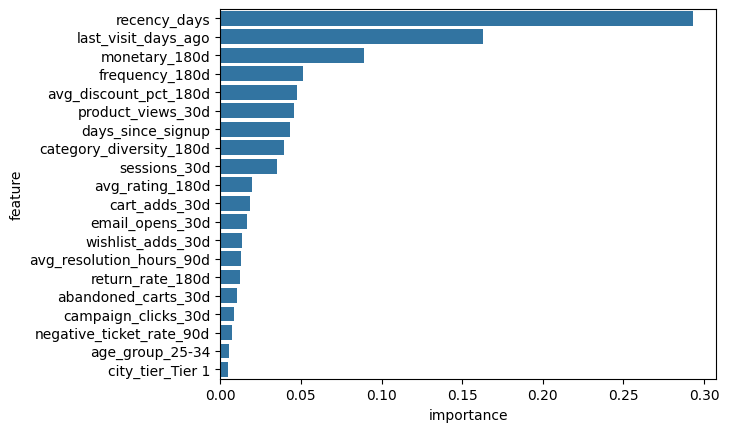

In [39]:
import os

top20 = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
    .head(20)
)

sns.barplot(

    data=top20,

    x="importance",

    y="feature"

)

# Create the 'outputs' directory if it doesn't exist
output_dir = "outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(
    os.path.join(output_dir, "feature_importance.png")
)

In [40]:
import shap

sample = X_test.sample(
    200,
    random_state=42
)

preprocessed = (
    rf_model.named_steps[
        "preprocessor"
    ]
    .transform(sample)
)

rf = rf_model.named_steps[
    "model"
]

explainer = shap.TreeExplainer(
    rf
)

shap_values = (
    explainer.shap_values(
        preprocessed
    )
)

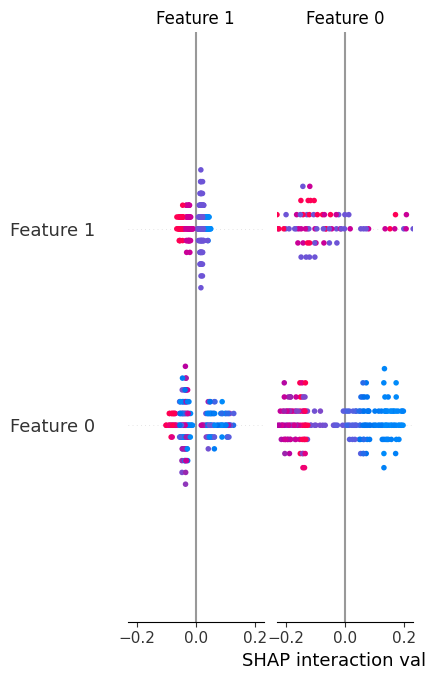

In [41]:
shap.summary_plot(

    shap_values,

    preprocessed,

    show=False

)

plt.savefig(
    "outputs/shap_summary.png"
)

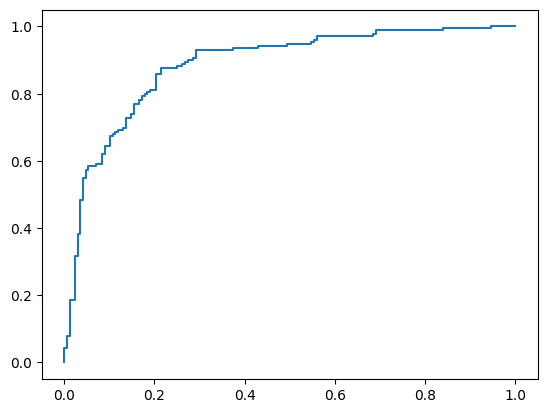

In [42]:
fpr,tpr,_ = roc_curve(
    y_test,
    test_prob
)

plt.plot(
    fpr,
    tpr
)

plt.savefig(
    "outputs/roc_curve.png"
)

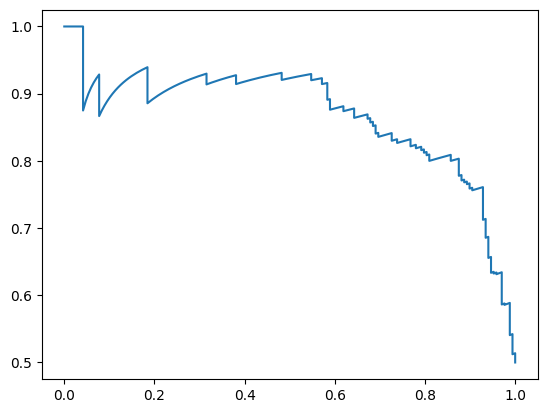

In [43]:
precision_curve,recall_curve,_ = (
    precision_recall_curve(
        y_test,
        test_prob
    )
)

plt.plot(
    recall_curve,
    precision_curve
)

plt.savefig(
    "outputs/pr_curve.png"
)

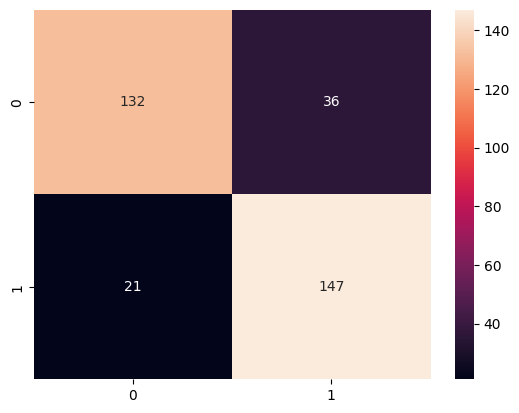

In [44]:
cm = confusion_matrix(
    y_test,
    test_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.savefig(
    "outputs/confusion_matrix.png"
)

In [45]:
import os

os.listdir('/content/outputs')

['pr_curve.png',
 'roc_curve.png',
 'shap_summary.png',
 'confusion_matrix.png',
 'feature_importance.png']

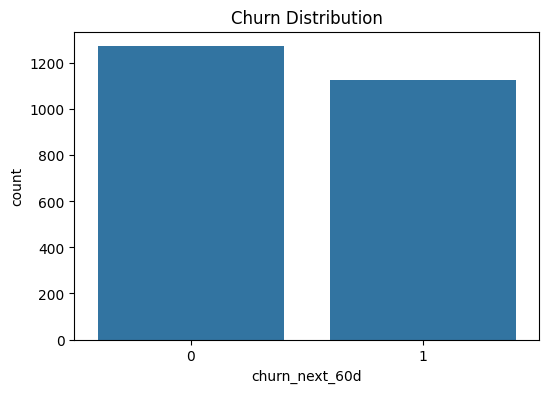

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="churn_next_60d",
    data=df
)

plt.title("Churn Distribution")

plt.savefig(
    "outputs/churn_distribution.png",
    bbox_inches="tight"
)

plt.show()

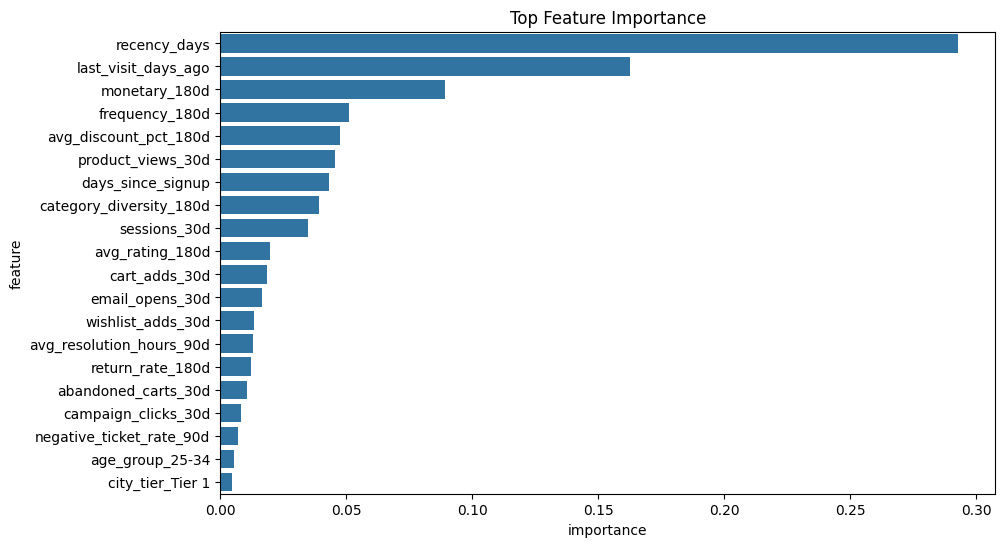

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x="importance",
    y="feature"
)

plt.title(
    "Top Feature Importance"
)

plt.savefig(
    "outputs/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [51]:
with open(
    "metrics.json"
) as f:

    print(
        f.read()
    )

{
    "accuracy": 0.8304,
    "precision": 0.8033,
    "recall": 0.875,
    "f1_score": 0.8376,
    "roc_auc": 0.8845,
    "pr_auc": 0.8688,
    "selected_threshold": 0.4,
    "confusion_matrix": {
        "true_negative": 132,
        "false_positive": 36,
        "false_negative": 21,
        "true_positive": 147
    }
}


In [52]:
files.download(
    "metrics.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

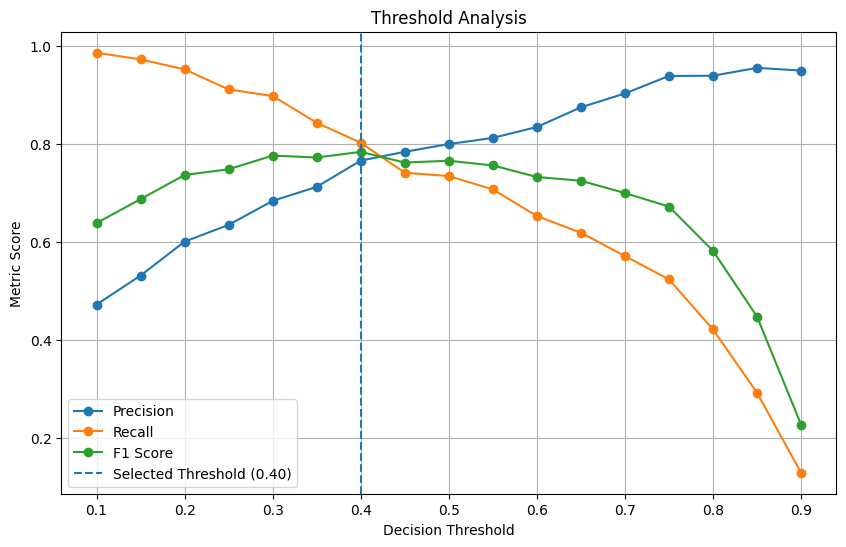

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    x=0.40,
    linestyle="--",
    label="Selected Threshold (0.40)"
)

plt.title(
    "Threshold Analysis"
)

plt.xlabel(
    "Decision Threshold"
)

plt.ylabel(
    "Metric Score"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "outputs/threshold_analysis.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()